# Notebook 05 - Data Transformation with Pandas

**Topic:** Data Processing with Pandas  
**Subtopic:** Transformation

---

## Things to learn

- How to reshape data using `melt`, `pivot`, and `pivot_table`
- How to merge and join DataFrames correctly
- How to use `groupby` for aggregation and transformation
- How to work with datetime columns
- How to apply functions with `apply`, `map`, and vectorised operations
- How to encode categorical variables

---

## Prerequisites

```bash
pip install pandas numpy matplotlib
```

---

## Section 1 - Imports and Dataset Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)
os.makedirs("output", exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Ready.")

Ready.


In [2]:
# We use three related tables to practice merges realistically

# Table 1: Employees
employees = pd.DataFrame({
    "employee_id" : [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "name"        : ["Alice Martin", "Bob Smith", "Carol White", "David Lee",
                     "Eve Johnson", "Frank Brown", "Grace Kim", "Henry Davis",
                     "Iris Wilson", "Jack Moore"],
    "department_id": [1, 2, 1, 3, 2, 4, 1, 3, 4, 2],
    "salary"      : [72000, 58000, 95000, 64000, 71000, 88000, 102000, 77000, 91000, 53000],
    "join_date"   : pd.to_datetime(["2019-03-15", "2021-07-22", "2018-11-01", "2020-05-10",
                                    "2023-01-30", "2015-09-14", "2017-04-28", "2022-08-05",
                                    "2019-12-19", "2024-02-11"]),
    "performance_score": [4.2, 3.8, 4.6, 4.5, 3.1, 4.0, 4.7, 3.5, 4.3, 3.9],
})

# Table 2: Departments
departments = pd.DataFrame({
    "department_id"  : [1, 2, 3, 4, 5],
    "department_name": ["Engineering", "Marketing", "HR", "Finance", "Legal"],
    "location"       : ["New York", "London", "Berlin", "Singapore", "Dubai"],
    "budget_usd"     : [500000, 300000, 150000, 400000, 200000],
})

# Table 3: Monthly sales targets
# Wide format: one column per month (this is a common format you will need to reshape)
sales_wide = pd.DataFrame({
    "employee_id": [102, 105, 110],
    "Jan_2024"   : [42000, 38000, 31000],
    "Feb_2024"   : [45000, 40000, 29000],
    "Mar_2024"   : [51000, 37000, 35000],
    "Apr_2024"   : [48000, 43000, 33000],
    "May_2024"   : [55000, 41000, 37000],
    "Jun_2024"   : [52000, 46000, 36000],
})

print("employees shape :", employees.shape)
print("departments shape:", departments.shape)
print("sales_wide shape :", sales_wide.shape)
employees.head()

employees shape : (10, 6)
departments shape: (5, 4)
sales_wide shape : (3, 7)


,employee_id,name,department_id,salary,join_date,performance_score
0,101,Alice Martin,1,72000,2019-03-15,4.2
1,102,Bob Smith,2,58000,2021-07-22,3.8
2,103,Carol White,1,95000,2018-11-01,4.6
3,104,David Lee,3,64000,2020-05-10,4.5
4,105,Eve Johnson,2,71000,2023-01-30,3.1


---

## Section 2 - Merging and Joining DataFrames

Merging is the most fundamental transformation in data work. Understanding the four join types is essential.

| Join type | Keeps rows from | Use when |
|---|---|---|
| `inner` | Both tables (matching only) | You only want complete records |
| `left` | Left table always, right when matched | You want all left records with optional info from right |
| `right` | Right table always, left when matched | Rarely used; equivalent to swapping left |
| `outer` | Both tables, NaN where no match | You want to see all records and identify gaps |

In [3]:
# Inner join: only employees whose department_id exists in the departments table
df_inner = employees.merge(departments, on="department_id", how="inner")
print(f"Inner join rows: {len(df_inner)} (out of {len(employees)} employees)")
df_inner[["name", "department_name", "location", "salary"]].head()

Inner join rows: 10 (out of 10 employees)


,name,department_name,location,salary
0,Alice Martin,Engineering,New York,72000
1,Bob Smith,Marketing,London,58000
2,Carol White,Engineering,New York,95000
3,David Lee,HR,Berlin,64000
4,Eve Johnson,Marketing,London,71000


In [4]:
# Left join: all employees, with department info where available
# Note: department 5 (Legal) has no employees, so it won't appear
df = employees.merge(departments, on="department_id", how="left")
print(f"Left join rows: {len(df)}")
print(f"\nDepartments in the data: {df['department_name'].unique()}")
print(f"Department 5 (Legal) appears: {'Legal' in df['department_name'].values}")

Left join rows: 10

Departments in the data: ['Engineering' 'Marketing' 'HR' 'Finance']
Department 5 (Legal) appears: False


In [5]:
# Outer join: see all employees AND all departments, identifying any gaps
df_outer = employees.merge(departments, on="department_id", how="outer")
print(f"Outer join rows: {len(df_outer)}")
print("\nRows with no matching employees (departments without staff):")
print(df_outer[df_outer["employee_id"].isnull()][["department_name", "location"]])

Outer join rows: 11

Rows with no matching employees (departments without staff):
   department_name location
10           Legal    Dubai


In [6]:
# Merging on columns with different names
# Suppose the departments table had the key named 'dept_id' instead
dept_renamed = departments.rename(columns={"department_id": "dept_id"})
df_diff_keys = employees.merge(dept_renamed, left_on="department_id", right_on="dept_id", how="left")
print(f"Merge with different key names: {df_diff_keys.shape}")

Merge with different key names: (10, 10)


---

## Section 3 - Reshaping: Wide to Long with `melt`

Data often arrives in **wide format** (one column per time period or category). For analysis and plotting you usually need **long format** (one row per observation).

Wide format:
```
employee_id | Jan_2024 | Feb_2024 | Mar_2024
102         | 42000    | 45000    | 51000
```

Long format:
```
employee_id | month    | sales
102         | Jan_2024 | 42000
102         | Feb_2024 | 45000
102         | Mar_2024 | 51000
```

In [7]:
print("Wide format (original):")
print(sales_wide.to_string())

Wide format (original):
   employee_id  Jan_2024  Feb_2024  Mar_2024  Apr_2024  May_2024  Jun_2024
0          102     42000     45000     51000     48000     55000     52000
1          105     38000     40000     37000     43000     41000     46000
2          110     31000     29000     35000     33000     37000     36000


In [8]:
sales_long = sales_wide.melt(
    id_vars="employee_id",    # Column(s) to keep as identifier
    var_name="month",          # Name for the new column holding the old column headers
    value_name="sales_usd"     # Name for the new column holding the values
)

# Sort for readability
sales_long = sales_long.sort_values(["employee_id", "month"]).reset_index(drop=True)

print(f"Long format shape: {sales_long.shape}  (was {sales_wide.shape})")
print(sales_long.head(9).to_string())

Long format shape: (18, 3)  (was (3, 7))
   employee_id     month  sales_usd
0          102  Apr_2024      48000
1          102  Feb_2024      45000
2          102  Jan_2024      42000
3          102  Jun_2024      52000
4          102  Mar_2024      51000
5          102  May_2024      55000
6          105  Apr_2024      43000
7          105  Feb_2024      40000
8          105  Jan_2024      38000


---

## Section 4 - Reshaping: Long to Wide with `pivot_table`

`pivot_table` is the reverse of `melt`. It is also the correct tool for building summary tables.

In [9]:
# Build a summary table: average salary by department and location
salary_pivot = df.pivot_table(
    values="salary",
    index="department_name",
    aggfunc={"salary": ["mean", "max", "count"]}
).round(0)

salary_pivot.columns = ["avg_salary", "count", "max_salary"]
salary_pivot = salary_pivot.sort_values("avg_salary", ascending=False)
print(salary_pivot.to_string())

                 avg_salary   count  max_salary
department_name                                
Engineering               3  102000     89667.0
Marketing                 3   71000     60667.0
Finance                   2   91000     89500.0
HR                        2   77000     70500.0


In [10]:
# Pivot the long sales data back to wide
sales_back_wide = sales_long.pivot_table(
    index="employee_id",
    columns="month",
    values="sales_usd",
    aggfunc="sum"
).reset_index()

print("Pivoted back to wide format:")
print(sales_back_wide.to_string())

Pivoted back to wide format:
month  employee_id  Apr_2024  Feb_2024  Jan_2024  Jun_2024  Mar_2024  May_2024
0              102     48000     45000     42000     52000     51000     55000
1              105     43000     40000     38000     46000     37000     41000
2              110     33000     29000     31000     36000     35000     37000


---

## Section 5 - GroupBy: Aggregation and Transformation

`groupby` is the most powerful single operation in pandas. There are two very different use cases:

- **Aggregation** reduces the group to one row (e.g. mean per department)
- **Transformation** keeps the same number of rows but computes group-level values (e.g. each row gets the mean salary of its department)

In [11]:
# Aggregation: one row per department
dept_summary = df.groupby("department_name").agg(
    headcount       = ("employee_id", "count"),
    avg_salary      = ("salary", "mean"),
    avg_performance = ("performance_score", "mean"),
    min_join_year   = ("join_date", lambda x: x.dt.year.min()),
).round(2)

print(dept_summary.to_string())

                 headcount  avg_salary  avg_performance  min_join_year
department_name                                                       
Engineering              3    89666.67             4.50           2017
Finance                  2    89500.00             4.15           2015
HR                       2    70500.00             4.00           2020
Marketing                3    60666.67             3.60           2021


In [12]:
# Transformation: add group statistics back to each row
df["dept_avg_salary"]   = df.groupby("department_name")["salary"].transform("mean").round(0)
df["salary_vs_dept_avg"] = (df["salary"] - df["dept_avg_salary"]).round(0)

# Positive = earns above department average, negative = below
print("Each employee's salary vs their department average:")
print(df[["name", "department_name", "salary", "dept_avg_salary", "salary_vs_dept_avg"]].to_string())

Each employee's salary vs their department average:
           name department_name  salary  dept_avg_salary  salary_vs_dept_avg
0  Alice Martin     Engineering   72000          89667.0            -17667.0
1     Bob Smith       Marketing   58000          60667.0             -2667.0
2   Carol White     Engineering   95000          89667.0              5333.0
3     David Lee              HR   64000          70500.0             -6500.0
4   Eve Johnson       Marketing   71000          60667.0             10333.0
5   Frank Brown         Finance   88000          89500.0             -1500.0
6     Grace Kim     Engineering  102000          89667.0             12333.0
7   Henry Davis              HR   77000          70500.0              6500.0
8   Iris Wilson         Finance   91000          89500.0              1500.0
9    Jack Moore       Marketing   53000          60667.0             -7667.0


In [13]:
# Multiple aggregations in one pass
perf_by_dept = df.groupby("department_name")["performance_score"].agg(
    ["mean", "std", "min", "max"]
).round(2)

print("Performance score statistics by department:")
print(perf_by_dept.to_string())

Performance score statistics by department:
                 mean   std  min  max
department_name                      
Engineering      4.50  0.26  4.2  4.7
Finance          4.15  0.21  4.0  4.3
HR               4.00  0.71  3.5  4.5
Marketing        3.60  0.44  3.1  3.9


---

## Section 6 - Datetime Operations

Datetime columns unlock a powerful set of transformations. Always convert to `datetime64` first with `pd.to_datetime`.

In [14]:
today = pd.Timestamp("today").normalize()

# Extract components
df["join_year"]   = df["join_date"].dt.year
df["join_month"]  = df["join_date"].dt.month
df["join_quarter"]= df["join_date"].dt.quarter
df["join_weekday"]= df["join_date"].dt.day_name()

# Compute duration
df["tenure_days"]  = (today - df["join_date"]).dt.days
df["tenure_years"] = (df["tenure_days"] / 365.25).round(1)

print(df[["name", "join_date", "join_year", "join_quarter", "tenure_years"]].to_string())

           name  join_date  join_year  join_quarter  tenure_years
0  Alice Martin 2019-03-15       2019             1           7.1
1     Bob Smith 2021-07-22       2021             3           4.7
2   Carol White 2018-11-01       2018             4           7.4
3     David Lee 2020-05-10       2020             2           5.9
4   Eve Johnson 2023-01-30       2023             1           3.2
5   Frank Brown 2015-09-14       2015             3          10.6
6     Grace Kim 2017-04-28       2017             2           9.0
7   Henry Davis 2022-08-05       2022             3           3.7
8   Iris Wilson 2019-12-19       2019             4           6.3
9    Jack Moore 2024-02-11       2024             1           2.2


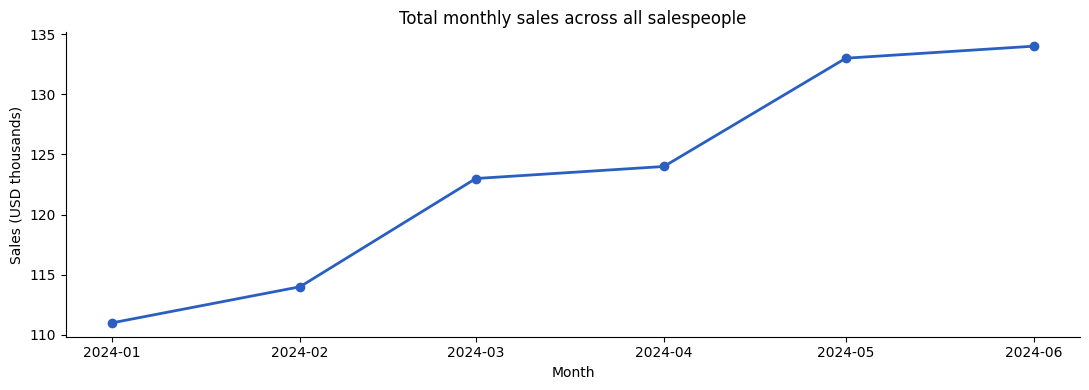

In [15]:
# Resampling: aggregate the sales data by month
# First attach employee names to the long sales data
sales_with_name = sales_long.merge(
    employees[["employee_id", "name"]], on="employee_id"
)

# Convert month string to proper datetime
sales_with_name["month_dt"] = pd.to_datetime(sales_with_name["month"], format="%b_%Y")

# Total sales across all salespeople per month
monthly_total = (
    sales_with_name
    .groupby("month_dt")["sales_usd"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(monthly_total["month_dt"], monthly_total["sales_usd"] / 1000,
        marker="o", linewidth=2, color="#2a5fc1")
ax.set_title("Total monthly sales across all salespeople")
ax.set_ylabel("Sales (USD thousands)")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig("output/transformation_monthly_sales.png", dpi=120)
plt.show()

---

## Section 7 - Applying Functions: `apply`, `map`, and Vectorised Operations

There is a performance hierarchy you should always follow:

1. **Vectorised pandas/numpy operations** - fastest, always prefer these
2. **`.map()`** - for element-wise lookups and simple transformations on a Series
3. **`.apply()`** - for row-wise or column-wise logic that cannot be vectorised
4. **Python `for` loop** - slowest, almost never appropriate on a DataFrame

In [16]:
# Method 1: Vectorised (fastest)
# Compute a bonus as a percentage of salary based on performance score
df["bonus_usd"] = (df["salary"] * df["performance_score"] * 0.01).round(0)
print("Bonus computed (vectorised):")
print(df[["name", "salary", "performance_score", "bonus_usd"]].head().to_string())

Bonus computed (vectorised):
           name  salary  performance_score  bonus_usd
0  Alice Martin   72000                4.2     3024.0
1     Bob Smith   58000                3.8     2204.0
2   Carol White   95000                4.6     4370.0
3     David Lee   64000                4.5     2880.0
4   Eve Johnson   71000                3.1     2201.0


In [17]:
# Method 2: map - element-wise lookup using a dictionary
performance_label_map = {
    True : "High performer",
    False: "Standard",
}
df["performance_label"] = (df["performance_score"] >= 4.5).map(performance_label_map)

# map with a function
df["salary_band"] = df["salary"].map(
    lambda x: "Senior" if x >= 90000 else ("Mid" if x >= 65000 else "Junior")
)

print(df[["name", "performance_score", "performance_label", "salary", "salary_band"]].to_string())

           name  performance_score performance_label  salary salary_band
0  Alice Martin                4.2          Standard   72000         Mid
1     Bob Smith                3.8          Standard   58000      Junior
2   Carol White                4.6    High performer   95000      Senior
3     David Lee                4.5    High performer   64000      Junior
4   Eve Johnson                3.1          Standard   71000         Mid
5   Frank Brown                4.0          Standard   88000         Mid
6     Grace Kim                4.7    High performer  102000      Senior
7   Henry Davis                3.5          Standard   77000         Mid
8   Iris Wilson                4.3          Standard   91000      Senior
9    Jack Moore                3.9          Standard   53000      Junior


In [18]:
# Method 3: apply - when logic depends on multiple columns
def compute_risk_flag(row):
    """
    Flag an employee as at-risk if performance is below 4.0
    AND they have been here more than 3 years.
    """
    low_performance = row["performance_score"] < 4.0
    long_tenure     = row["tenure_years"] > 3
    return int(low_performance and long_tenure)

df["at_risk_flag"] = df.apply(compute_risk_flag, axis=1)
print(f"At-risk employees: {df['at_risk_flag'].sum()}")
print(df[df["at_risk_flag"] == 1][["name", "department_name", "performance_score", "tenure_years"]].to_string())

At-risk employees: 3
          name department_name  performance_score  tenure_years
1    Bob Smith       Marketing                3.8           4.7
4  Eve Johnson       Marketing                3.1           3.2
7  Henry Davis              HR                3.5           3.7


---

## Section 8 - Encoding Categorical Variables

Machine learning models require numeric inputs. Categorical columns must be encoded before training.

In [19]:
# Method 1: One-hot encoding (get_dummies)
# Use for nominal categories with no inherent order (department, location)

df_encoded = pd.get_dummies(df[["name", "department_name", "salary"]],
                             columns=["department_name"],
                             prefix="dept",
                             drop_first=True)  # Drop first to avoid dummy variable trap

print("After one-hot encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

After one-hot encoding:
['name', 'salary', 'dept_Finance', 'dept_HR', 'dept_Marketing']


,name,salary,dept_Finance,dept_HR,dept_Marketing
0,Alice Martin,72000,False,False,False
1,Bob Smith,58000,False,False,True
2,Carol White,95000,False,False,False
3,David Lee,64000,False,True,False
4,Eve Johnson,71000,False,False,True


In [20]:
# Method 2: Ordinal encoding
# Use for ordered categories where order matters (Junior < Mid < Senior)

band_order = {"Junior": 0, "Mid": 1, "Senior": 2}
df["salary_band_encoded"] = df["salary_band"].map(band_order)

print("Ordinal encoding of salary_band:")
print(df[["name", "salary_band", "salary_band_encoded"]].to_string())

Ordinal encoding of salary_band:
           name salary_band  salary_band_encoded
0  Alice Martin         Mid                    1
1     Bob Smith      Junior                    0
2   Carol White      Senior                    2
3     David Lee      Junior                    0
4   Eve Johnson         Mid                    1
5   Frank Brown         Mid                    1
6     Grace Kim      Senior                    2
7   Henry Davis         Mid                    1
8   Iris Wilson      Senior                    2
9    Jack Moore      Junior                    0


In [21]:
# Method 3: Label encoding using Categorical dtype
df["dept_code"] = pd.Categorical(df["department_name"]).codes

print("Label encoding of department_name:")
print(df[["name", "department_name", "dept_code"]].to_string())
print("\nNote: Label encoding implies an order that does not exist.")
print("Use one-hot encoding for nominal categories in ML models.")

Label encoding of department_name:
           name department_name  dept_code
0  Alice Martin     Engineering          0
1     Bob Smith       Marketing          3
2   Carol White     Engineering          0
3     David Lee              HR          2
4   Eve Johnson       Marketing          3
5   Frank Brown         Finance          1
6     Grace Kim     Engineering          0
7   Henry Davis              HR          2
8   Iris Wilson         Finance          1
9    Jack Moore       Marketing          3

Note: Label encoding implies an order that does not exist.
Use one-hot encoding for nominal categories in ML models.


---

## Section 9 - String Transformations on Text Columns

The `.str` accessor gives you vectorised string operations on an entire column without looping.

In [ ]:
# Split name into first and last name
df["first_name"] = df["name"].str.split().str[0]
df["last_name"]  = df["name"].str.split().str[-1]

# Create a fallback email column if it does not exist yet
if "email" not in df.columns:
    df["email"] = (
        df["first_name"].str.lower()
        + "."
        + df["last_name"].str.lower()
        + "@company.com"
    )

# Extract domain from email
df["email_domain"] = df["email"].str.split("@").str[-1]

# Check if name contains a pattern
df["name_has_vowel_start"] = df["first_name"].str[0].str.lower().isin(list("aeiou"))

print(df[["name", "email", "first_name", "last_name", "email_domain"]].head(8).to_string())

KeyError: 'email'

---

## Section 10 - Sorting, Ranking, and Windowing

In [ ]:
# Rank employees by salary within their department
df["salary_rank_in_dept"] = df.groupby("department_name")["salary"].rank(
    method="dense", ascending=False
).astype(int)

print("Salary rank within each department:")
print(
    df[["name", "department_name", "salary", "salary_rank_in_dept"]]
    .sort_values(["department_name", "salary_rank_in_dept"])
    .to_string()
)

In [ ]:
# Rolling average on the monthly sales data
sales_with_name = sales_with_name.sort_values(["employee_id", "month_dt"])

sales_with_name["rolling_3m_avg"] = (
    sales_with_name
    .groupby("employee_id")["sales_usd"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    .round(0)
)

print("3-month rolling average sales per employee:")
print(sales_with_name[["name", "month", "sales_usd", "rolling_3m_avg"]].to_string())

---

## Section 11 - Save Transformed Data

In [ ]:
df.to_csv("output/employees_transformed.csv", index=False)
sales_long.to_csv("output/sales_long.csv", index=False)

print("Saved employees_transformed.csv")
print("Saved sales_long.csv")
print(f"\nFinal column list ({len(df.columns)} columns):")
print(df.columns.tolist())

---

## Section 12 - Transformation Reference

| Operation | Method | Output shape |
|---|---|---|
| Combine two tables | `df.merge()` | Same or more rows |
| Wide to long | `df.melt()` | More rows, fewer columns |
| Long to wide | `df.pivot_table()` | Fewer rows, more columns |
| Summarise by group | `groupby().agg()` | One row per group |
| Add group stat to each row | `groupby().transform()` | Same shape |
| Apply custom logic per row | `df.apply(axis=1)` | Same number of rows |
| Element-wise lookup | `series.map(dict)` | Same number of rows |
| One-hot encoding | `pd.get_dummies()` | Same rows, more columns |

---

**Practice challenge:** Merge the `sales_long` table onto the main `df` table, compute each salesperson's total 6-month revenue, and add it as a new column. For employees who are not in the sales data, fill with 0.